In [8]:
## Tools
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [10]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv, description="Query Arxiv Papers")
print(arxiv.name)   

arxiv


In [7]:
arxiv.invoke("How's the future of Genrative AI?")

'Published: 2017-10-24\nTitle: Multi-messenger Observations of a Binary Neutron Star Merger\nAuthors: LIGO Scientific Collaboration, Virgo Collaboration, Fermi GBM, INTEGRAL, IceCube Collaboration, AstroSat Cadmium Zinc Telluride Imager Team, IPN Collaboration, The Insight-Hxmt Collaboration, ANTARES Collaboration, The Swift Collaboration, AGILE Team, The 1M2H Team, The Dark Energy Camera GW-EM Collaboration, the DES Collaboration, The DLT40 Collaboration, GRAWITA, :, GRAvitational Wave Inaf TeAm, '

In [12]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [2]:
import os 
from dotenv import load_dotenv
load_dotenv()

os.environ['TAVILY_API_KEY'] = os.getenv("TAVILY_API_KEY")
os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")

In [3]:
## Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\hp\AppData\Local\Temp\ipykernel_15376\1622265974.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [4]:
tavily.invoke("Provide me the latest Genrative NEWS.")

[{'title': 'Generative AI news and analysis - TechCrunch',
  'url': 'https://techcrunch.com/tag/generative-ai/',
  'content': '### Topics\n\nLatest\n\nAI\n\nAmazon\n\nApps\n\nBiotech & Health\n\nClimate\n\nCloud Computing\n\nCommerce\n\nCrypto\n\nEnterprise\n\nEVs\n\nFintech\n\nFundraising\n\nGadgets\n\nGaming\n\nGoogle\n\nGovernment & Policy\n\nHardware\n\nInstagram\n\nLayoffs\n\nMedia & Entertainment\n\nMeta\n\nMicrosoft\n\nPrivacy\n\nRobotics\n\nSecurity\n\nSocial\n\nSpace\n\nStartups\n\nTikTok\n\nTransportation\n\nVenture\n\n### More from TechCrunch\n\nStaff\n\nEvents\n\nStartup Battlefield\n\nStrictlyVC\n\nNewsletters\n\nPodcasts\n\nVideos\n\nPartner Content\n\nTechCrunch Brand Studio\n\nCrunchboard\n\nContact Us\n\n# Generative AI\n\nTechCrunch covers the latest news and analysis in Generative AI (GenAI). Read the latest on startups and founders building artificial intelligence tools. From OpenAI with ChatGPT, to Google with Gemini—TechCrunch covers the entire ecosystem.\n\n### \

In [13]:
## Combine all this tools in the list
tools = [arxiv, wiki, tavily]

In [22]:
## Initialize the LLM model
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3-32b")

In [23]:
llm.invoke("What is AI?")

AIMessage(content="<think>\nOkay, the user asked, What is AI? I need to explain AI in a simple and clear way, avoiding jargon. The user might be a student or someone new to the field, so I should start with the basics. AI, or artificial intelligence, is about making machines do smart things. But how to define it? Maybe say it's the simulation of human intelligence in machines.\n\nI should mention different areas like learning, problem-solving, perception, and language understanding. Also, it's important to note the types of AI: narrow AI, which is what we have now, doing specific tasks, and general AI, which is still theoretical. Examples like Siri or self-driving cars can help make it relatable.\n\nWait, the user might not know about machine learning and deep learning. I should explain that these are subsets of AI. Maybe mention how AI uses data to improve over time. Also, touch on current applications and potential future developments. But keep it concise. Avoid going too technical. 

In [25]:
llm_with_tools = llm.bind_tools(tools=tools)

In [26]:
## Exicute this call

llm_with_tools.invoke("What is the recent news on AI?")

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for recent news on AI. I need to figure out which tool to use here. Let me check the available tools.\n\nFirst, there\'s the Arxiv Papers function, which is for academic papers. But the user is asking about news, not research papers. So probably not Arxiv.\n\nNext, Wikipedia. That\'s for general knowledge and facts, but it might not have the most up-to-date news. Wikipedia can be a bit slow to update with current events.\n\nThen there\'s Tavily Search Results JSON. The description says it\'s optimized for current events. That sounds perfect for recent news. The user wants the latest updates, so using Tavily makes sense here.\n\nSo I should call Tavily with the query "recent news on AI". Let me make sure the parameters are correct. The function requires a "query" parameter, which I\'ll set to "recent news on AI". \n\nDouble-checking, no other tools seem appropriate. Arxiv is for papers, Wikipedia for

In [27]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage ## Human message or AI message
from typing import Annotated ## Labelling
from langgraph.graph.message import add_messages ## Reducers in Langgraph

In [ ]:
class State(TypedDict):
    message = Annotated[list[AnyMessage], add_messages]

In [29]:
## Entire Chatboard with Langgraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

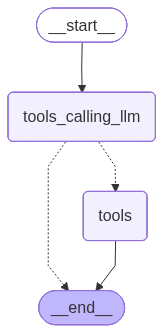

In [37]:
## Node Definition
def tools_calling_llm(state: State):
    return {"message":[llm_with_tools.invoke(state["messages"])]}

## Build Graph
builder = StateGraph(State)
builder.add_node("tools_calling_llm", tools_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Edges
builder.add_edge(START, "tools_calling_llm")
builder.add_conditional_edges(
    "tools_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools.
    # Is the latest message (result) from assistant is not a tools call -> tools_condition routes to END.
    tools_condition
)
builder.add_edge("tools", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))